In [1]:
from io import StringIO
import matplotlib.pyplot as plt
import pandas as pd
import os,glob
os.chdir('F:\\geodata\\river_runoff_obs')

In [2]:
# Raw data as a string
data = """
abbre,ssp126,ssp245,ssp370,ssp585
hsg, 	2020,	2019,	2021,	2021
dsk,	2026,	2027,	2029,	2032
xhl,	2042,	2053,	2055,	2049
slglk,	2042,	2054,	2056,	2058
kq,		2055,	2077,	2074,	2078
wlwt,	2064,	2077,	2093,	2084
tgzlk,	2069,	2080,	2094,	2094
"""

# Use StringIO to simulate a file
data_io = StringIO(data)

# Read the data into a DataFrame
peak_water_df = pd.read_csv(data_io,index_col=0)

# Display the DataFrame
print(peak_water_df)

       ssp126  ssp245  ssp370  ssp585
abbre                                
hsg      2020    2019    2021    2021
dsk      2026    2027    2029    2032
xhl      2042    2053    2055    2049
slglk    2042    2054    2056    2058
kq       2055    2077    2074    2078
wlwt     2064    2077    2093    2084
tgzlk    2069    2080    2094    2094


In [3]:
colors = ['#00008B', '#FFA500', '#FF0000', '#B22222']  # Define colors for the 4 scenarios

In [4]:
file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

In [5]:
import pymannkendall as mk

hsg ssp126
hsg ssp245
hsg ssp370
hsg ssp585
dsk ssp126
dsk ssp245
dsk ssp370
dsk ssp585
xhl ssp126
xhl ssp245
xhl ssp370
xhl ssp585
slglk ssp126
slglk ssp245
slglk ssp370
slglk ssp585
kq ssp126
kq ssp245
kq ssp370
kq ssp585
wlwt ssp126
wlwt ssp245
wlwt ssp370
wlwt ssp585
tgzlk ssp126
tgzlk ssp245
tgzlk ssp370
tgzlk ssp585


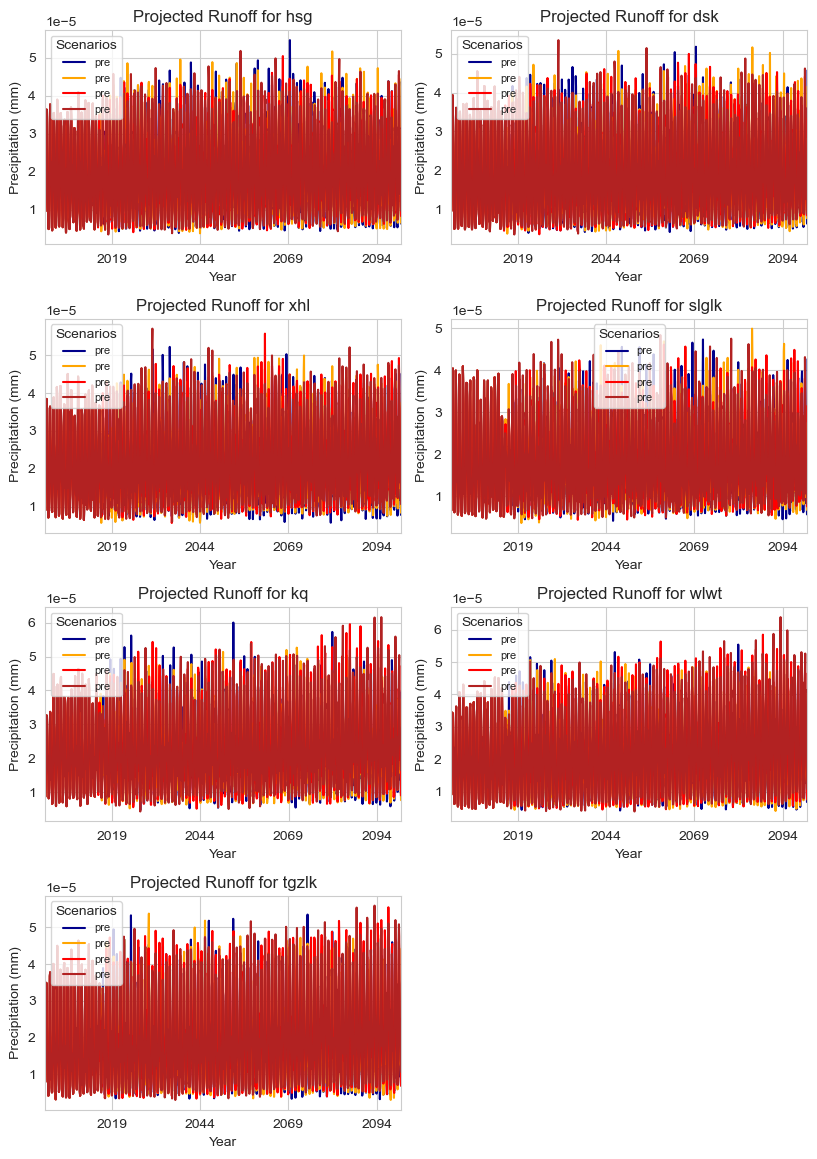

In [6]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        # Plot the mean 'pre' for the current scenario with color

        mean_df['pre'].plot(ax=ax, color=colors[j])
        # ax.plot(
        #     # mean_df.index,
        #     mean_df['pre'],
        #     label=scenario,
        #     color=colors[j]  # Set the color based on the scenario index
        # )
        # ax.fill_between(
        #     annual_std_dev.index,
        #     -annual_std_dev['pre'] + annual_mean_df['pre'],
        #     annual_std_dev['pre'] + annual_mean_df['pre'],
        #     color=colors[j],  # Set the color based on the scenario index
        #     alpha=0.3,
        # )

    # Customize the subplot
    ax.set_title(f'Projected Runoff for {abbre}')
    # ax.set_xlim(2000, 2100)
    ax.set_xlabel('Year')
    ax.set_ylabel('Precipitation (mm)')
    ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

In [7]:
csv_list = os.listdir(r"F:\geodata\river_runoff_obs")

In [8]:
mean_df

,dis,tm,pre,ep,gr,Projected_Runoff,Projected_Evaporation
time,,,,,,,
2000-02-01,9.845721,261.006679,0.000008,30.532414,0.000000e+00,11.523910,26.432086
2000-03-01,10.148387,265.226964,0.000018,54.243871,0.000000e+00,12.552821,53.548320
2000-04-01,13.583333,271.016420,0.000028,90.959333,0.000000e+00,15.554807,88.436640
2000-05-01,52.506452,277.385097,0.000035,132.774194,4.824613e+03,50.529213,139.863178
2000-06-01,132.123333,281.222226,0.000033,173.096000,4.911962e+06,93.370622,169.299223
...,...,...,...,...,...,...,...
2100-08-01,NaN,286.060670,0.000026,NaN,2.711480e+09,1392.731750,392.140710
2100-09-01,NaN,281.547357,0.000022,NaN,6.585741e+08,447.738706,178.125461
2100-10-01,NaN,276.203755,0.000014,NaN,3.634251e+06,79.565939,117.920794


In [9]:
mon_df_list[0]

,dis,tm,pre,ep,gr,Projected_Runoff,Projected_Evaporation
time,,,,,,,
2000-02-01,9.845357,260.202797,0.000006,30.532414,0.000000e+00,12.868307,19.031368
2000-03-01,10.148387,264.710897,0.000025,54.243871,0.000000e+00,14.171896,58.926712
2000-04-01,13.583333,269.630026,0.000029,90.959333,0.000000e+00,11.826323,90.114750
2000-05-01,52.506452,275.891319,0.000029,132.774194,4.824613e+03,81.220400,132.315690
2000-06-01,132.123333,282.808142,0.000020,173.096000,4.911962e+06,84.538010,177.229570
...,...,...,...,...,...,...,...
2100-08-01,NaN,287.396607,0.000006,NaN,2.711480e+09,1986.908300,597.261000
2100-09-01,NaN,283.188978,0.000026,NaN,6.585741e+08,618.966400,235.840500
2100-10-01,NaN,275.753355,0.000025,NaN,3.634251e+06,80.349140,126.524990


In [10]:
mon_df_list[1]

,dis,tm,pre,ep,gr,Projected_Runoff,Projected_Evaporation
time,,,,,,,
2000-02-01,9.846207,256.463174,0.000004,30.532414,0.000000e+00,10.725418,30.270890
2000-03-01,10.148387,261.367804,0.000002,54.243871,0.000000e+00,15.427834,38.403976
2000-04-01,13.583333,265.405028,0.000009,90.959333,0.000000e+00,18.763260,78.266550
2000-05-01,52.506452,269.462341,0.000025,132.774194,4.824613e+03,42.687527,140.920730
2000-06-01,132.123333,271.285835,0.000041,173.096000,4.911962e+06,80.658270,160.238080
...,...,...,...,...,...,...,...
2100-08-01,NaN,282.271987,0.000047,NaN,2.711480e+09,1461.746100,415.687130
2100-09-01,NaN,277.734081,0.000030,NaN,6.585741e+08,471.828980,183.499440
2100-10-01,NaN,274.360563,0.000026,NaN,3.634251e+06,124.922844,154.263520


hsg ssp126 -0.018101635432312024 -0.0041182428399545445
hsg ssp245 -0.0013731115393389448 0.007972653428128806
hsg ssp370 0.01599111735337644 0.03316365698113666
hsg ssp585 0.034103974771240164 0.05870411584513602
dsk ssp126 0.015455013266382212 0.0279128173003671
dsk ssp245 0.02581901405257847 0.041558808740889575
dsk ssp370 0.042922273951754075 0.05974907031844956
dsk ssp585 0.06602675052154106 0.0752975685328563
xhl ssp126 0.0277349400836695 0.029182169610214137
xhl ssp245 0.04124409038888932 0.058241417819147934
xhl ssp370 0.05417457479002974 0.07752371299525529
xhl ssp585 0.07584269816044231 0.09527448755624812
slglk ssp126 0.016738139164973243 0.030040877469996063
slglk ssp245 0.022898555316924973 0.037788500671635195
slglk ssp370 0.024665202290241828 0.04713640008907749
slglk ssp585 0.03800970919959257 0.05291082103606115
kq ssp126 0.01603834836142548 0.012625950896080429
kq ssp245 0.03645077860459245 0.026411896141958158
kq ssp370 0.09013667747099618 0.12078923821913201
kq ssp5

C:\Users\HP\AppData\Local\Temp\ipykernel_126308\416374655.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


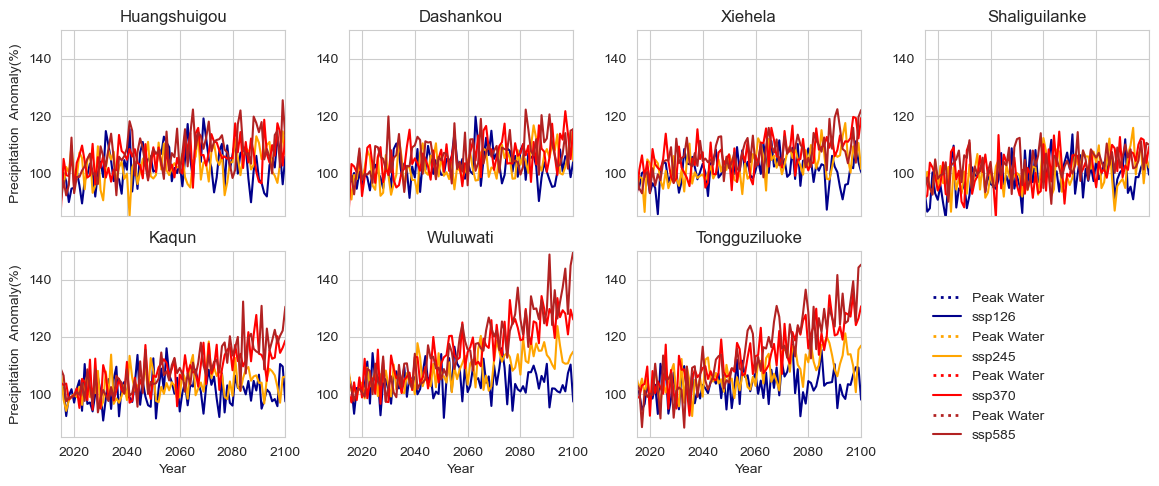

In [11]:
mon_df_list[2]
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        peak_water_timing = float(peak_water_df.loc[abbre,scenario])
        peak_water = annual_mean_df['pre'][int(peak_water_timing)]
        ax.vlines(x=float(peak_water_df.loc[abbre,scenario]), ymin = 0  * peak_water, ymax = peak_water, colors=colors[j], linestyles='dotted', linewidth=2, label='Peak Water')
        # Plot the mean 'pre' for the current scenario with color
        ax.plot(
            annual_mean_df.index,
            annual_mean_df['pre']/annual_mean_df.loc[2000:2015,'pre'].mean() *100,
            label=scenario,
            color=colors[j]  # Set the color based on the scenario index
        )
        # ax.fill_between(
        #     annual_std_dev.index,
        #     -annual_std_dev['pre'] + annual_mean_df['pre'],
        #     annual_std_dev['pre'] + annual_mean_df['pre'],
        #     color=colors[j],  # Set the color based on the scenario index
        #     alpha=0.3,
        # )

        # Get the peak water year for the current station and scenario
        peak_year = peak_water_df.loc[abbre, scenario]
        # Split data into before and after peak water year
        before_peak = annual_mean_df['pre'][annual_mean_df.index < peak_year-15]
        after_peak  = annual_mean_df['pre'][annual_mean_df.index >= peak_year+15]
        during_peak = annual_mean_df['pre'][
            (annual_mean_df.index >= peak_year - 15) & (annual_mean_df['pre'] < peak_year+15)
        ]

        # mk_result_before = mk.original_test(before_peak)
        # mk_result_after  = mk.original_test( after_peak)
        # print(abbre, scenario, mk_result_before.slope, mk_result_before.p, mk_result_after.slope,mk_result_after.p , '\n')
        print(abbre, scenario, during_peak.mean()/ before_peak.mean()-1,after_peak.mean()/before_peak.mean()-1)
        # mk_result  = mk.original_test(annual_mean_df['pre'])
        # print(abbre, scenario,mk_result.trend)

    # Customize the subplot
    ax.set_title(station_names[i])
    ax.set_xlim(2015, 2100)
    ax.set_ylim(bottom = 85)
    ax.set_ylim(top = 150)
    ax.set_xlabel('Year')
    ax.set_ylabel(r'Precipitation  Anomaly(%)')
    # ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    ax.ticklabel_format(style='plain', axis='y')

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# Adjust layout
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figure_prcp_river_runoff.svg')
plt.show()

hsg ssp245
hsg ssp585
dsk ssp245
dsk ssp585
xhl ssp245
xhl ssp585
slglk ssp245
slglk ssp585
kq ssp245
kq ssp585
wlwt ssp245
wlwt ssp585
tgzlk ssp245
tgzlk ssp585


C:\Users\HP\AppData\Local\Temp\ipykernel_126308\4120400279.py:141: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


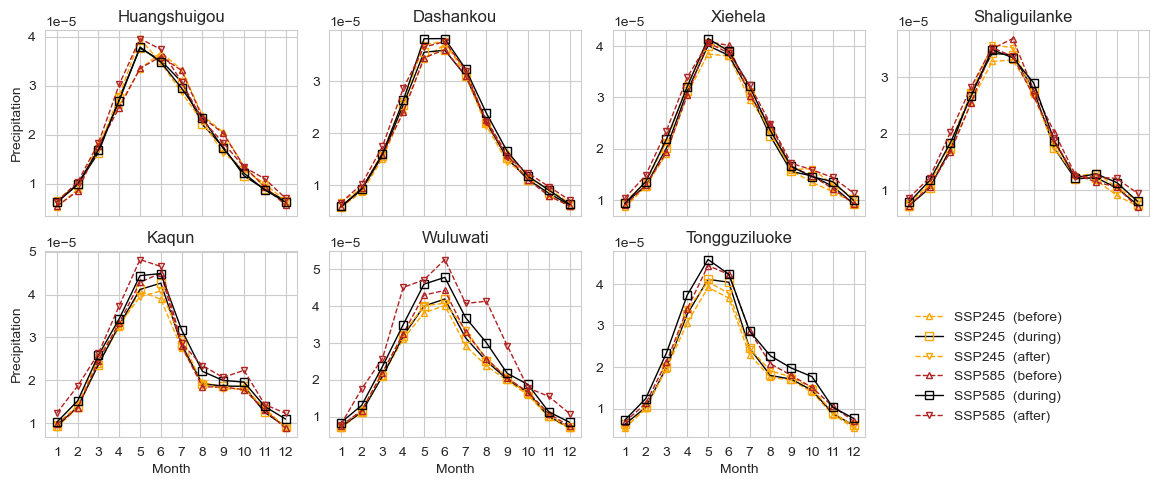

In [12]:
annual_mean_df['Projected_Runoff'][2005]
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp245', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # if peak_water_df.loc[abbre,scenario] > 2055:
        #     continue

        # Split data into 3 periods
        before_peak_water_df = mean_df[(mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15)&
                                       (mean_df.index.year >= float(peak_water_df.loc[abbre, scenario]) - 30)]
        after_peak_water_df  = mean_df[(mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 45)]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'pre' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['pre'],
            label=f"{scenario.upper()}  (before)",
            color=colors[2*j +1],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )
        ax.plot(
            during_mean_df.index,
            during_mean_df['pre'],
            label=f"{scenario.upper()}  (during)",
            color='black',  # Set the color based on the scenario index
            marker="s",        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            markeredgecolor= colors[2*j +1] if scenario!='ssp585' else 'black',  # Set the color based on the scenario index
            linestyle='-',
            linewidth=1,
            markersize=6
        )
        ax.plot(
            after_mean_df.index,
            after_mean_df['pre'],
            label=f"{scenario.upper()}  (after)",
            color=colors[2*j +1],  # Set the color based on the scenario index
            marker='v',        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )
        # # print(((during_mean_df['Projected_Runoff'][5:8] / before_mean_df['Projected_Runoff'])[5:8]).mean() -1)
        # before_mean_df['Projected_Runoff'].index = before_mean_df['Projected_Runoff'].replace(month_mapping)
        # during_mean_df['Projected_Runoff'].index = during_mean_df['Projected_Runoff'].replace(month_mapping)
        # after_mean_df['Projected_Runoff'].index = after_mean_df['Projected_Runoff'].replace(month_mapping)

        # before_center_of_mass = (before_mean_df.index.astype('int64') * before_mean_df['Projected_Runoff']).sum() / before_mean_df['Projected_Runoff'].sum()
        # during_center_of_mass = (during_mean_df.index.astype('int64') * during_mean_df['Projected_Runoff']).sum() / during_mean_df['Projected_Runoff'].sum()
        # after_center_of_mass = (after_mean_df.index.astype('int64') * after_mean_df['Projected_Runoff']).sum() / after_mean_df['Projected_Runoff'].sum()
        # print(station_names[i],scenario,before_center_of_mass,during_center_of_mass,after_center_of_mass)


        # print(station_names[i],scenario,'before',((before_mean_df['Projected_Runoff'][5:8].sum() / before_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'during',((during_mean_df['Projected_Runoff'][5:8].sum() / during_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Precipitation')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'


# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure4_1_SSP245_SSP585.svg')
plt.show()

hsg ssp126 -0.003127458975612036 0.04713225718403957 

hsg ssp245 0.016045660735374445 2.435718293725131e-11 

hsg ssp370 0.038929899912455185 0.0 

hsg ssp585 0.04623974125956565 0.0 

dsk ssp126 -0.004001255838295571 0.03824394082660132 

dsk ssp245 0.017014749493831784 3.6931235847248445e-10 

dsk ssp370 0.04247827466069756 0.0 

dsk ssp585 0.05215827300877573 0.0 

xhl ssp126 -0.004192907844969651 0.013969321230510312 

xhl ssp245 0.018187422186942317 1.1275647082698015e-11 

xhl ssp370 0.04239214628885303 0.0 

xhl ssp585 0.05318979832273859 0.0 

slglk ssp126 -0.0036153926203351646 0.026311665180940524 

slglk ssp245 0.018092426849280262 1.0389467064442215e-12 

slglk ssp370 0.04082615863963023 0.0 

slglk ssp585 0.0520911920676414 0.0 

kq ssp126 -0.005329210275418106 0.005619463727721152 

kq ssp245 0.021772689472412152 2.9976021664879227e-14 

kq ssp370 0.04555758545962686 0.0 

kq ssp585 0.05907404598790209 0.0 

wlwt ssp126 -0.003986403976700578 0.08252967800576494 

wlwt ss

C:\Users\HP\AppData\Local\Temp\ipykernel_126308\3356139958.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


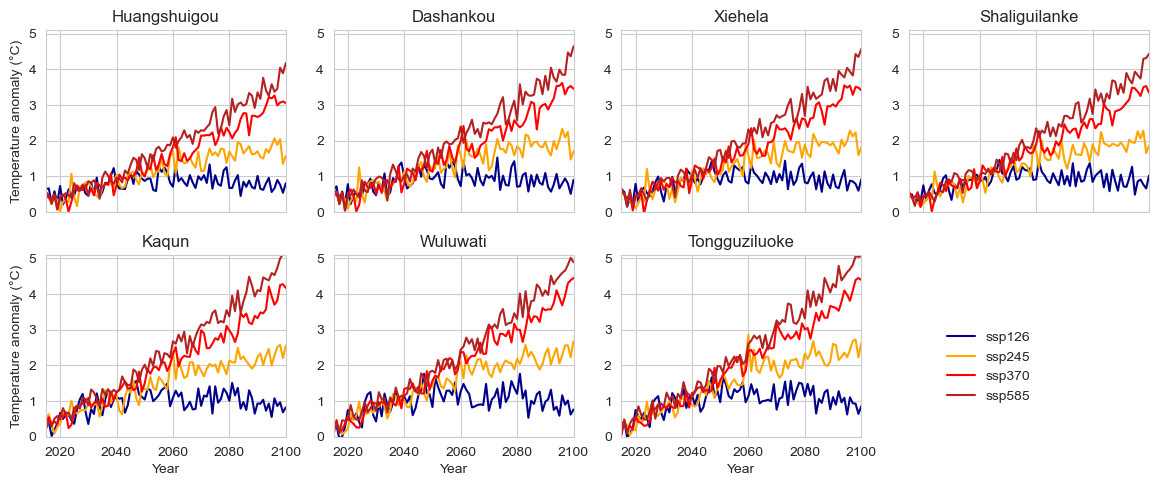

In [13]:
mon_df_list[2]
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        peak_water_timing = float(peak_water_df.loc[abbre,scenario])
        peak_water = annual_mean_df['tm'][int(peak_water_timing)]
        # ax.vlines(x=float(peak_water_df.loc[abbre,scenario]), ymin = 0  * peak_water, ymax = peak_water, colors=colors[j], linestyles='dotted', linewidth=2, label='Peak Water')
        # Plot the mean 'tm' for the current scenario with color
        ax.plot(
            annual_mean_df.index,
            annual_mean_df['tm'] - annual_mean_df.loc[2000:2015,'tm'].mean(),
            label=scenario,
            color=colors[j]  # Set the color based on the scenario index
        )
        # ax.fill_between(
        #     annual_std_dev.index,
        #     -annual_std_dev['tm'] + annual_mean_df['tm'],
        #     annual_std_dev['tm'] + annual_mean_df['tm'],
        #     color=colors[j],  # Set the color based on the scenario index
        #     alpha=0.3,
        # )

        # Get the peak water year for the current station and scenario
        peak_year = peak_water_df.loc[abbre, scenario]
        # Split data into before and after peak water year
        before_peak = annual_mean_df['tm'][annual_mean_df.index < peak_year-15]
        after_peak  = annual_mean_df['tm'][annual_mean_df.index >= 2040]
        during_peak = annual_mean_df['tm'][
            (annual_mean_df.index >= peak_year - 15) & (annual_mean_df['tm'] < peak_year+15)
        ]

        mk_result_before = mk.original_test(before_peak)
        mk_result_after  = mk.original_test( after_peak)
        print(abbre, scenario,  mk_result_after.slope,mk_result_after.p , '\n')
        # print(abbre, scenario, during_peak.mean()/ before_peak.mean()-1,after_peak.mean()/before_peak.mean()-1)
        # mk_result  = mk.original_test(annual_mean_df['tm'])
        # print(abbre, scenario,mk_result.trend)

    # Customize the subplot
    ax.set_title(station_names[i])
    ax.set_xlim(2015, 2100)
    ax.set_ylim(top = 5.1)
    ax.set_ylim(bottom = 0)
    ax.set_xlabel('Year')
    ax.set_ylabel(r'Temperature anomaly (°C)')
    # ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    ax.ticklabel_format(style='plain', axis='y')

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# Adjust layout
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figure_tm_river_runoff.svg')
plt.show()

hsg ssp245
-0.0764509686881526
hsg ssp585
-0.057932407194161484
dsk ssp245


<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_126308\4088950292.py:101: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


-0.013740829404262467
dsk ssp585
0.05760782775002138
xhl ssp245
-0.0322872584252939
xhl ssp585
-0.00127012969237561
slglk ssp245
-0.05090697708064218
slglk ssp585
-0.017234254374745128
kq ssp245
-0.016742554158374223
kq ssp585
0.13577133195132607
wlwt ssp245
0.09880498289918904
wlwt ssp585
0.2626430044711823
tgzlk ssp245
0.09743343278616945
tgzlk ssp585
0.2567406953526892


C:\Users\HP\AppData\Local\Temp\ipykernel_126308\4088950292.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


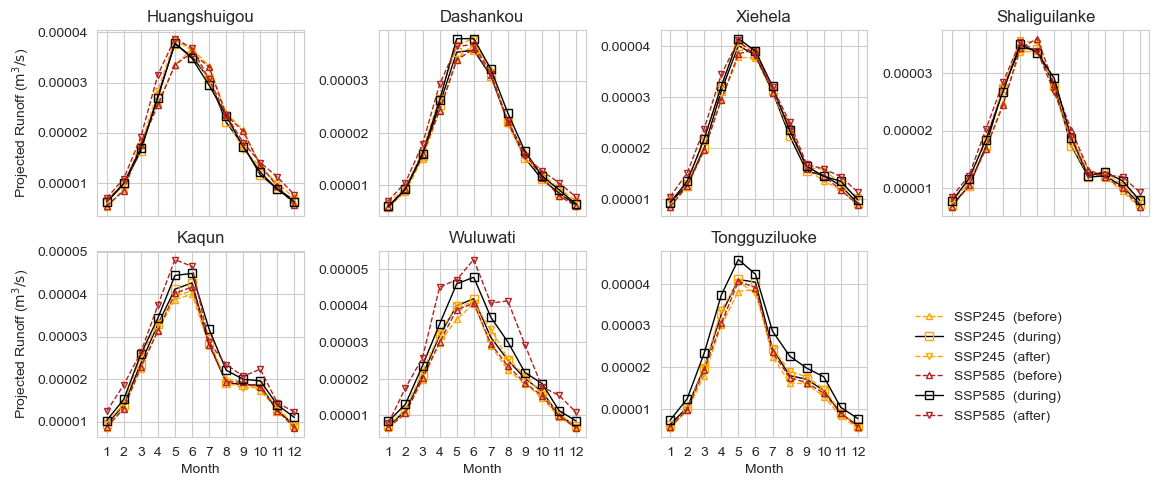

In [14]:
annual_mean_df['pre'][2005]
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp245', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'pre' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['pre'],
            label=f"{scenario.upper()}  (before)",
            color=colors[2*j +1],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )
        ax.plot(
            during_mean_df.index,
            during_mean_df['pre'],
            label=f"{scenario.upper()}  (during)",
            color='black',  # Set the color based on the scenario index
            marker="s",        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            markeredgecolor= colors[2*j +1] if scenario!='ssp585' else 'black',  # Set the color based on the scenario index
            linestyle='-',
            linewidth=1,
            markersize=6
        )
        ax.plot(
            after_mean_df.index,
            after_mean_df['pre'],
            label=f"{scenario.upper()}  (after)",
            color=colors[2*j +1],  # Set the color based on the scenario index
            marker='v',        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )
        print(((during_mean_df['pre'][6:8] / before_mean_df['pre'])[6:8]).mean() -1)

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure_prcp_1_SSP245_SSP585.svg')
plt.show()

hsg ssp126
-0.03740751668146136
hsg ssp245


<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_126308\2635881486.py:100: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


-0.04299348482009435
hsg ssp370
-0.03287848053337661
hsg ssp585
-0.033857364243217836
dsk ssp126
-0.0008029283322559255
dsk ssp245
-0.01792258177079442
dsk ssp370
0.012961713706311162
dsk ssp585
0.06386586528660176
xhl ssp126
0.030829259008942733
xhl ssp245
-0.0030919889686111812
xhl ssp370
-0.0037484868413070194
xhl ssp585
0.020745031668566227
slglk ssp126
-0.023596342340467813
slglk ssp245
-0.033565029791719936
slglk ssp370
-0.022570617903562407
slglk ssp585
-0.032502895281102284
kq ssp126
-0.003552738590225646
kq ssp245
0.012701452083458076
kq ssp370
0.0716366796604313
kq ssp585
0.09810320153966456
wlwt ssp126
0.026085341591207456
wlwt ssp245
0.08260531690847994
wlwt ssp370
0.1769663805267887
wlwt ssp585
0.20662727163898476
tgzlk ssp126
0.01995422253182566
tgzlk ssp245
0.07686572549581738
tgzlk ssp370
0.16425807506793544
tgzlk ssp585
0.18761414984442304


C:\Users\HP\AppData\Local\Temp\ipykernel_126308\2635881486.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


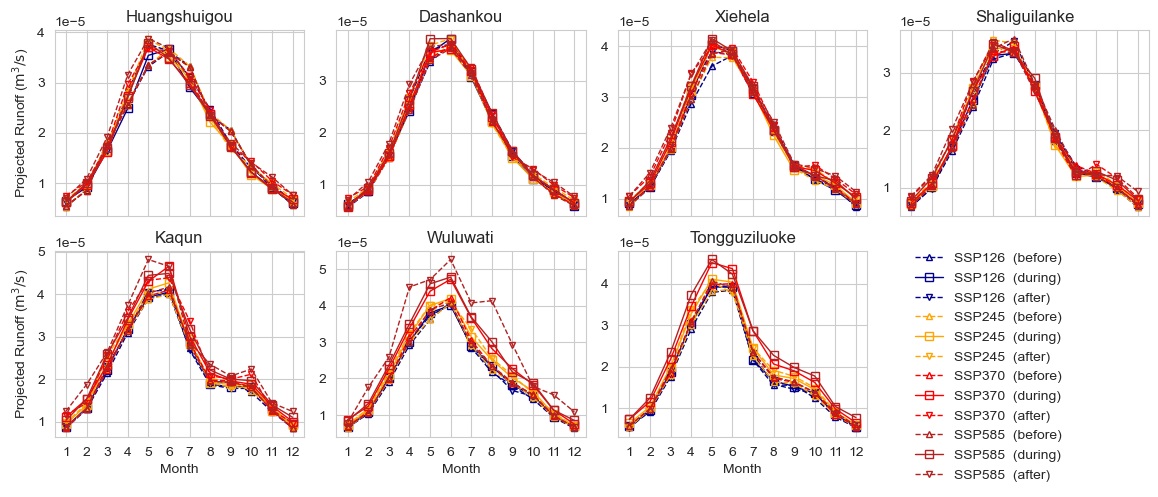

In [15]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'pre' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['pre'],
            label=f"{scenario.upper()}  (before)",
            color=colors[j],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

        ax.plot(
            during_mean_df.index,
            during_mean_df['pre'],
            label=f"{scenario.upper()}  (during)",
            color=colors[j],  # Set the color based on the scenario index
            marker="s",        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='-',
            linewidth=1,
            markersize=6
        )
        ax.plot(
            after_mean_df.index,
            after_mean_df['pre'],
            label=f"{scenario.upper()}  (after)",
            color=colors[j],  # Set the color based on the scenario index
            marker='v',        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )
        print(((during_mean_df['pre'][4:9] / before_mean_df['pre'])[4:9]).mean() -1)

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure_prcp_1.svg')
plt.show()

In [16]:
mean_df

,dis,tm,pre,ep,gr,Projected_Runoff,Projected_Evaporation
time,,,,,,,
2000-02-01,9.845721,261.006679,0.000008,30.532414,0.000000e+00,11.523910,26.432086
2000-03-01,10.148387,265.226964,0.000018,54.243871,0.000000e+00,12.552821,53.548320
2000-04-01,13.583333,271.016420,0.000028,90.959333,0.000000e+00,15.554807,88.436640
2000-05-01,52.506452,277.385097,0.000035,132.774194,4.824613e+03,50.529213,139.863178
2000-06-01,132.123333,281.222226,0.000033,173.096000,4.911962e+06,93.370622,169.299223
...,...,...,...,...,...,...,...
2100-08-01,NaN,286.060670,0.000026,NaN,2.711480e+09,1392.731750,392.140710
2100-09-01,NaN,281.547357,0.000022,NaN,6.585741e+08,447.738706,178.125461
2100-10-01,NaN,276.203755,0.000014,NaN,3.634251e+06,79.565939,117.920794


In [17]:
(after_mean_df['pre'] / before_mean_df['pre'])[4:9].mean()

nan

In [18]:
before_mean_df

,dis,tm,pre,ep,gr,Projected_Runoff,Projected_Evaporation
month,,,,,,,
1,12.029211,260.644234,0.000006,17.932361,0.000000e+00,12.350367,20.712498
2,11.140891,263.275829,0.000010,37.536535,0.000000e+00,12.795139,32.585780
3,11.072785,267.192537,0.000019,59.342492,3.272735e+01,13.890355,60.225769
4,15.279273,272.147696,0.000031,93.748995,4.388689e+04,20.734670,99.085689
5,36.632851,278.002368,0.000041,137.725474,6.576300e+05,59.208820,148.151459
6,110.610674,282.540620,0.000039,173.414356,4.004641e+07,171.392666,177.472457
7,310.342486,284.859240,0.000024,176.585626,7.276908e+08,529.332768,205.292419
8,334.450830,283.205355,0.000017,162.166144,9.545097e+08,605.859356,217.556737
9,94.728054,277.828585,0.000016,120.223721,3.729178e+07,129.906185,136.931677
